# 03 - Evaluation Framework Demonstration

This notebook demonstrates the evaluation utilities developed for the
sentiment-analysis research framework.

The evaluation framework calculates:

- macro-averaged precision;
- macro-averaged recall;
- macro-averaged F1;
- confusion matrices; and
- class distributions.

Synthetic demonstration predictions are used in this notebook.

The results are demonstrations of the evaluation implementation and
must not be interpreted as empirical findings from Reddit users.

In [1]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation import (
    calculate_metrics,
    create_confusion_matrix,
    create_class_distribution,
    generate_classification_report,
)

In [2]:
y_true = [
    "Positive",
    "Positive",
    "Neutral",
    "Negative",
    "Negative",
    "Neutral",
    "Positive",
    "Negative",
    "Neutral",
    "Positive",
]

y_pred = [
    "Positive",
    "Neutral",
    "Neutral",
    "Negative",
    "Positive",
    "Neutral",
    "Positive",
    "Negative",
    "Negative",
    "Positive",
]

In [3]:
evaluation_data = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
})

evaluation_data

,true_label,predicted_label
0,Positive,Positive
1,Positive,Neutral
2,Neutral,Neutral
3,Negative,Negative
4,Negative,Positive
5,Neutral,Neutral
6,Positive,Positive
7,Negative,Negative
8,Neutral,Negative
9,Positive,Positive


In [4]:
metrics = calculate_metrics(
    y_true,
    y_pred,
)

metrics

{'precision_macro': 0.6944444444444443,
 'recall_macro': 0.6944444444444443,
 'macro_f1': 0.6944444444444443}

In [5]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Score": [
        metrics["precision_macro"],
        metrics["recall_macro"],
        metrics["macro_f1"]
    ]
})

metrics_df

,Metric,Score
0,Macro Precision,0.694444
1,Macro Recall,0.694444
2,Macro F1,0.694444


In [6]:
labels = [
    "Negative",
    "Neutral",
    "Positive",
]

confusion_df = create_confusion_matrix(
    y_true,
    y_pred,
    labels=labels,
)

confusion_df

,Negative,Neutral,Positive
Negative,2,0,1
Neutral,1,2,0
Positive,0,1,3


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

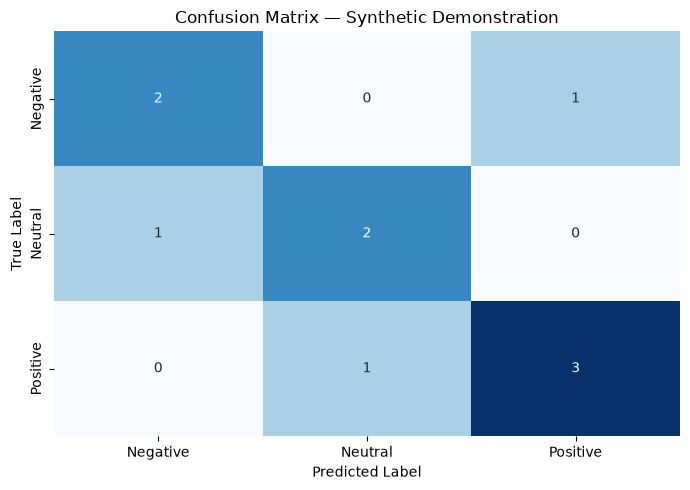

In [8]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)

plt.title("Confusion Matrix — Synthetic Demonstration")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [9]:
class_distribution = create_class_distribution(
    y_true
)

class_distribution

Positive    4
Neutral     3
Negative    3
Name: count, dtype: int64

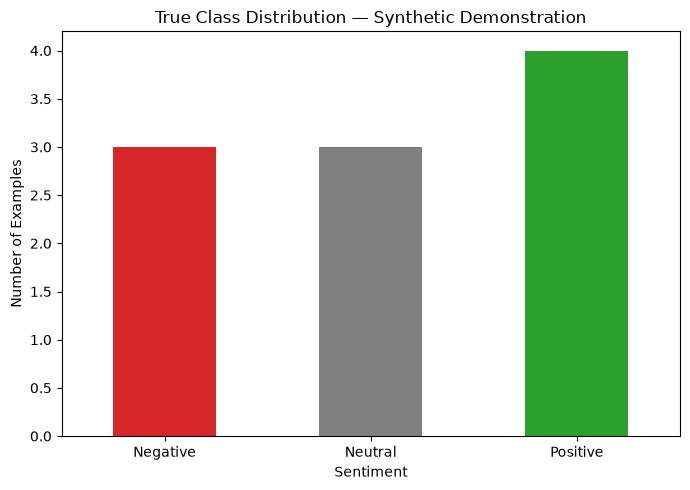

In [10]:
class_distribution = class_distribution.reindex(
    ["Negative", "Neutral", "Positive"]
)

class_distribution.plot(
    kind="bar",
    color=["#d62728", "#7f7f7f", "#2ca02c"],
    figsize=(7, 5),
)

plt.title("True Class Distribution — Synthetic Demonstration")
plt.xlabel("Sentiment")
plt.ylabel("Number of Examples")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
report = generate_classification_report(
    y_true,
    y_pred,
)

print(report)

              precision    recall  f1-score   support

    Negative       0.67      0.67      0.67         3
     Neutral       0.67      0.67      0.67         3
    Positive       0.75      0.75      0.75         4

    accuracy                           0.70        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.70      0.70      0.70        10



## Interpretation

The evaluation framework successfully calculates macro-averaged
precision, recall and F1-score from predicted and reference sentiment
labels.

The confusion matrix provides additional information about the types
of classification errors made between the three sentiment categories.

Class-distribution analysis is included because imbalanced sentiment
classes can influence the interpretation of overall performance.

Macro-F1 is used as the primary comparative metric because it gives
equal importance to each sentiment class rather than allowing the
largest class to dominate the result.

The data used in this notebook are synthetic demonstration examples.
Consequently, the reported values are not empirical results from the
planned Reddit dataset.